In [ ]:
import pandas as pd

df = pd.read_csv("C:\\Users\\SSAFY\\Desktop\\Total_Data_v2.csv", encoding='utf-8')

# print(df.info())


print(df.head())


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\SSAFY\\Desktop\\Total_Data_v2.csv'

In [ ]:
print(df.columns)

In [ ]:
print(df.info())

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score
from collections import defaultdict

# 데이터프레임 df가 이미 로드되었다고 가정합니다.

# 1. 목표 변수(Y) 정의 (폐업 여부)
# '급감여부(-20% YoY)'를 폐업 프록시로 사용합니다. NaN은 급감하지 않은(0)으로 처리합니다.
df['폐업_FLAG'] = df['급감여부(-20% YoY)'].fillna(0).astype(int)

# 2. 이상치 및 결측치 처리
# '-999999.9'를 NaN으로 변환
df = df.replace(-999999.9, np.nan)

# 수치형 변수 목록 (NaN 처리가 필요한 연속형 변수)
numerical_cols = [
    '배달매출금액 비율', '매출 안정성(변동성) CV(3개월)', '매출탄력도(6개월)',
    '동일 상권 내 매출 순위 비율_y', '동일 업종 내 해지 가맹점 비중_y',
    '고객분포_다양성지수', '재방문 고객 비중_y'
]

# 수치형 변수 결측치 중앙값 대체
for col in numerical_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(df[col].median())

# 3. 구간 변수 (Ordinal) 인코딩 및 점수화 준비
segment_cols = [
    '가맹점 운영개월수 구간', '매출금액 구간', '매출건수 구간',
    '유니크 고객 수 구간', '객단가 구간', '취소율 구간'
]

for col in segment_cols:
    # 1. 문자열 '5_75-90%' 등에서 '5'와 같은 숫자 부분만 추출
    score_col_name = col + '_SCORE'

    # astype(str)을 먼저 적용하여 문자열 처리가 가능하게 함
    extracted_score = df[col].astype(str).str.split('_').str[0]

    # 2. 추출된 문자열을 숫자로 변환 (변환 불가 시 errors='coerce'로 NaN 처리)
    numeric_score = pd.to_numeric(extracted_score, errors='coerce')

    # 3. NaN 값(변환 실패 값)을 0으로 대체 후, 안전하게 정수(int)로 변환
    df[score_col_name] = numeric_score.fillna(0).astype(int)

# 4. '취소율 구간' 역순 점수 변환
df['취소율_역순_SCORE'] = 6 - df['취소율 구간_SCORE']

In [ ]:
# Min-Max Scaler 초기화
scaler = MinMaxScaler()

# 5. 각 영역별 변수 정의 및 점수화 (0~1)

### 5-1. 영역 1: 거래 안정성 (Stability) ###
stability_cols = ['매출 안정성(변동성) CV(3개월)', '취소율_역순_SCORE']
stability_df = df[stability_cols].copy()

# CV는 낮을수록 좋으니 (1 - 값)
stability_df['매출CV_정규화'] = 1 - scaler.fit_transform(stability_df[['매출 안정성(변동성) CV(3개월)']])
# 취소율 역순점수는 높을수록 좋으니 그대로 정규화
stability_df['취소율_정규화'] = scaler.fit_transform(stability_df[['취소율_역순_SCORE']])

### 5-2. 영역 2: 매출 (Sales) ###
sales_cols = ['매출금액 구간_SCORE', '매출건수 구간_SCORE', '배달매출금액 비율']
sales_df = df[sales_cols].copy()
sales_df = pd.DataFrame(scaler.fit_transform(sales_df), columns=[f'{c}_정규화' for c in sales_cols], index=sales_df.index)

### 5-3. 영역 3: 상대적 평가 (Relative) ###
relative_cols = ['동일 상권 내 매출 순위 비율_y', '동일 업종 내 해지 가맹점 비중_y']
relative_df = df[relative_cols].copy()

# 순위 비율과 해지 비중은 낮을수록 좋으니 (1 - 값)
relative_df['순위_정규화'] = 1 - scaler.fit_transform(relative_df[['동일 상권 내 매출 순위 비율_y']])
relative_df['해지비중_정규화'] = 1 - scaler.fit_transform(relative_df[['동일 업종 내 해지 가맹점 비중_y']])

### 5-4. 영역 4: 고객 특성 (Customer) ###
customer_cols = ['유니크 고객 수 구간_SCORE', '객단가 구간_SCORE', '고객분포_다양성지수', '재방문 고객 비중_y']
customer_df = df[customer_cols].copy()
customer_df = pd.DataFrame(scaler.fit_transform(customer_df), columns=[f'{c}_정규화' for c in customer_cols], index=customer_df.index)

# 6. 종합 점수 생성 (가중치 없는 평균 사용)
df['score_거래 안정성'] = stability_df[['매출CV_정규화', '취소율_정규화']].mean(axis=1)
df['score_매출'] = 1 - sales_df.mean(axis=1)
df['score_상대적 평가'] = relative_df[['순위_정규화', '해지비중_정규화']].mean(axis=1)
df['score_고객 특성'] = customer_df.mean(axis=1)

# X 변수 준비
X = df[['score_거래 안정성', 'score_매출', 'score_상대적 평가', 'score_고객 특성']]
y = df['폐업_FLAG']

# 최종 X 변수 스케일링 (로지스틱 회귀에 사용될 최종 피처)
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# 학습/테스트 분리 (클래스 불균형을 고려하여 stratify=y 적용)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# Grid Search를 통한 최적 파라미터 탐색
param_grid = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear']
}

# 개선 전략 적용: class_weight='balanced' 추가 (Recall 개선 목적)
logreg_base = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')

# 최적 모델 탐색 (ROC AUC 기준)
grid_search = GridSearchCV(
    logreg_base,
    param_grid, cv=5, scoring='roc_auc', verbose=1, n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("\n### 3. Grid Search 최적 파라미터 탐색 결과 (불균형 처리) ###")
print("최적 하이퍼파라미터:", grid_search.best_params_)
print(f"최적 ROC AUC Score (교차 검증): {grid_search.best_score_:.4f}")

# 최적 모델 성능 평가
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]

print("\n### 최적화된 로지스틱 회귀 모델 (Test Set) 성능 ###")
print(classification_report(y_test, y_pred_best, target_names=['운영 중 (0)', '폐업 시그널 (1)']))
print(f"Test Set ROC AUC: {roc_auc_score(y_test, y_pred_proba_best):.4f}")

# 변수 해석 (회귀 계수)
coef_df = pd.DataFrame({'점수 영역': X.columns, '회귀 계수': best_model.coef_[0]})
print("\n### 최적 모델의 회귀 계수 (점수 영역별 영향력) ###")
print(coef_df.sort_values(by='회귀 계수', ascending=True))

In [ ]:
print("\n" + "=" * 50)
print("4. 업종별 로지스틱 회귀 모델 분석")
print("=" * 50)

industry_results = defaultdict(dict)
unique_industries = df['업종'].dropna().unique()
best_params = grid_search.best_params_

for biz in unique_industries:
    sub_df = df[df['업종'] == biz].copy()

    # 데이터 부족 및 폐업 시그널 부족 시 건너뛰기 (폐업 시그널이 10개 미만이면 학습 어려움)
    if len(sub_df) < 100 or sub_df['폐업_FLAG'].sum() < 10:
        continue

    X_biz = sub_df[['score_거래 안정성', 'score_매출', 'score_상대적 평가', 'score_고객 특성']]
    y_biz = sub_df['폐업_FLAG']

    # 업종 내 분포 기준으로 다시 스케일링 적용 (매우 중요)
    X_biz_scaled = scaler.fit_transform(X_biz)
    X_biz_scaled = pd.DataFrame(X_biz_scaled, columns=X_biz.columns)

    # 학습/테스트 분리
    X_train_biz, X_test_biz, y_train_biz, y_test_biz = train_test_split(
        X_biz_scaled, y_biz, test_size=0.3, random_state=42, stratify=y_biz
    )

    try:

        biz_model = LogisticRegression(
            penalty=best_params['penalty'],
            C=best_params['C'],
            solver=best_params['solver'],
            max_iter=1000,
            random_state=42,
            class_weight='balanced'
        )
        biz_model.fit(X_train_biz, y_train_biz)

        y_pred_proba_biz = biz_model.predict_proba(X_test_biz)[:, 1]
        roc_auc_biz = roc_auc_score(y_test_biz, y_pred_proba_biz)

        # 결과 저장
        industry_results[biz]['ROC_AUC'] = roc_auc_biz
        industry_results[biz]['계수'] = dict(zip(X_biz.columns, biz_model.coef_[0]))

        print(f"[{biz}] ROC AUC: {roc_auc_biz:.4f}")

    except Exception as e:
        print(f"[{biz}] 모델 학습 오류: {e}")

# 최종 업종별 결과 요약
print("\n최종 업종별 모델 ROC AUC 및 계수 요약:")
summary_df = pd.DataFrame.from_dict(industry_results, orient='index')
# print(summary_df.sort_values(by='ROC_AUC', ascending=False))

In [ ]:
# ✅ [1] 한글 폰트 설정 (운영체제별 자동 적용)
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우: 맑은 고딕
else:  # Linux, Colab 등
    plt.rcParams['font.family'] = 'NanumGothic'  # 나눔고딕 설치 필요 (apt install fonts-nanum)

plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지

In [ ]:
!sudo apt-get install -y fonts-nanum
!fc-cache -fv


In [ ]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# 업종별 ROC AUC 값 딕셔너리 생성
roc_auc_dict = {
    "햄버거": 0.9235,
    "커피전문점": 0.6359,
    "베이커리": 0.8281,
    "한식-육류/고기": 0.6798,
    "일반 유흥주점": 0.6739,
    "양식": 0.7150,
    "한식-단품요리일반": 0.6396,
    "한식-국밥/설렁탕": 0.7358,
    "치킨": 0.7135,
    "분식": 0.6769,
    "카페": 0.5916,
    "일식당": 0.5828,
    "백반/가정식": 0.6109,
    "한식-국수/만두": 0.5977,
    "동남아/인도음식": 0.8927,
    "농산물": 0.6937,
    "떡/한과 제조": 0.5630,
    "중식당": 0.8033,
    "요리주점": 0.5589,
    "와인바": 0.5745,
    "한식뷔페": 0.7430,
    "한식-해물/생선": 0.6859,
    "호프/맥주": 0.7176,
    "피자": 0.7654,
    "한식-감자탕": 0.8850,
    "샌드위치/토스트": 0.8587,
    "반찬": 0.7101,
    "미곡상": 0.9341,
    "식료품": 0.6638,
    "청과물": 0.5712,
    "일식-우동/소바/라면": 0.9314,
    "축산물": 0.5299,
    "주류": 0.8040,
    "꼬치구이": 1.0000,
    "아이스크림/빙수": 0.6876,
    "포장마차": 0.7338,
    "한식-죽": 1.0000,
    "일식-초밥/롤": 1.0000,
    "이자카야": 0.8344,
    "룸살롱/단란주점": 0.9718,
    "한식-찌개/전골": 0.7810,
    "인삼제품": 0.9353,
    "한식-냉면": 0.7790,
    "일식-덮밥/돈가스": 0.7305,
    "식품 제조": 0.7510,
    "떡/한과": 0.9600,
    "기타세계요리": 0.6636,
    "도시락": 1.0000,
    "건강식품": 0.9100,
    "담배": 1.0000
}

# 데이터프레임으로 변환
summary_df = pd.DataFrame(list(roc_auc_dict.items()), columns=['업종', 'ROC_AUC'])

# ROC_AUC 기준 내림차순 정렬
summary_df = summary_df.sort_values(by='ROC_AUC', ascending=False).reset_index(drop=True)

print(summary_df)


In [2]:
# 1. 비교할 업종 리스트 선택
target_industries = list(roc_auc_dict.keys())

# 2. 위에서 만든 coef_df_full (전체 계수 데이터)에서 해당 업종만 필터링
compare_df = coef_df_full.loc[target_industries].reset_index()

# 3. 'melt'를 사용해 Seaborn Grouped Bar Chart에 적합한 형태로 변환
compare_df_melted = compare_df.melt(
    id_vars='업종',
    value_vars=features,
    var_name='점수 영역',
    value_name='회귀 계수'
)

# 4. 그룹 막대그래프 시각화
plt.figure(figsize=(14, 7))
sns.barplot(
    data=compare_df_melted,
    x='업종',
    y='회귀 계수',
    hue='점수 영역',  # '점수 영역'별로 색상을 다르게
    palette='Set2'
)
plt.title('주요 업종별 변수 영향력 비교', fontsize=16)
plt.ylabel('회귀 계수 (영향력)')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--') # 0 기준선
plt.legend(title='점수 영역', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

NameError: name 'roc_auc_dict' is not defined

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54660 (\N{HANGUL SYLLABLE HAEM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48260 (\N{HANGUL SYLLABLE BEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45224 (\N{HANGUL SYLLABLE NAM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/us

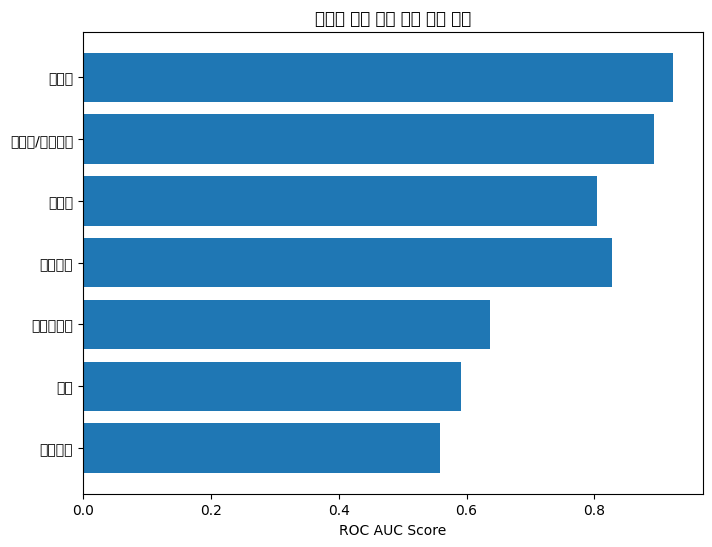

In [1]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우: 맑은 고딕
plt.rcParams['axes.unicode_minus'] = False     # 마이너스 깨짐 방지


# 예시 데이터
roc_by_category = {
    '햄버거': 0.9235, '동남아/인도음식': 0.8927, '중식당': 0.8033, '베이커리': 0.8281,
    '커피전문점': 0.6359, '카페': 0.5916, '요리주점': 0.5589
}

plt.figure(figsize=(8,6))
plt.barh(list(roc_by_category.keys()), list(roc_by_category.values()))
plt.xlabel('ROC AUC Score')
plt.title('업종별 폐업 예측 모델 성능 비교')
plt.gca().invert_yaxis()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

coef_df = pd.DataFrame({
    '점수영역': ['매출', '거래 안정성', '상대적 평가', '고객 특성'],
    '회귀계수': [-2.263, -1.281, -0.826, -0.181]
})

plt.figure(figsize=(6,4))
plt.bar(coef_df['점수영역'], coef_df['회귀계수'])
plt.title('폐업 영향 주요 요인별 회귀 계수')
plt.ylabel('회귀 계수 (음수일수록 폐업확률 ↑)')
plt.show()


In [ ]:
import seaborn as sns

# 예시: 업종별 주요 score 영향
data = {
    '햄버거': {'score_매출': -2.5, 'score_거래 안정성': -1.8, 'score_고객 특성': -0.5},
    '커피전문점': {'score_매출': -1.1, 'score_거래 안정성': -0.9, 'score_고객 특성': -0.3},
    '중식당': {'score_매출': -1.9, 'score_거래 안정성': -1.2, 'score_고객 특성': -0.4}
}

df_heat = pd.DataFrame(data).T  # 전치
sns.heatmap(df_heat, annot=True, cmap="RdBu_r", center=0)
plt.title("업종별 주요 점수 영향도(회귀계수)")
plt.show()


In [ ]:
roc_df = pd.DataFrame(list(roc_by_category.items()), columns=['업종', 'ROC_AUC'])
roc_df.sort_values('ROC_AUC', ascending=False).head(5)

# roc_df.sort_values('ROC_AUC', ascending=False).tail(5)


In [ ]:
import pandas as pd

perf_df = pd.DataFrame({
    '지표': ['정확도', '폐업 Recall', 'ROC AUC'],
    '값': [0.60, 0.56, 0.622]
})
perf_df



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. 모델 정의
rf_clf = RandomForestClassifier(
    n_estimators=300,      # 트리 개수
    max_depth=8,           # 트리 깊이
    min_samples_split=10,  # 내부 노드 분할 최소 샘플 수
    min_samples_leaf=5,    # 리프 노드 최소 샘플 수
    random_state=42,
    class_weight='balanced'  # 클래스 불균형 자동 보정
)

# 2. 학습
rf_clf.fit(X_train, y_train)

# 3. 예측
y_pred_prob = rf_clf.predict_proba(X_test)[:, 1]
y_pred = (y_pred_prob > 0.5).astype(int)

# 4. 평가
print("ROC AUC:", roc_auc_score(y_test, y_pred_prob))
print("\n분류 리포트:\n", classification_report(y_test, y_pred))

# 5. (선택) 중요 변수 시각화
import matplotlib.pyplot as plt
import pandas as pd

importances = pd.Series(rf_clf.feature_importances_, index=X_train.columns)
importances.sort_values().plot(kind='barh', figsize=(8,4))
plt.title("Feature Importance (RandomForest)")
plt.show()


In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# 1. 혼동 행렬 계산
cm = confusion_matrix(y_test, y_pred)

# 2. Seaborn을 사용한 시각화
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
# 1️⃣ 예측 확률 추가
df['폐업_예측확률'] = rf_clf.predict_proba(X_scaled)[:, 1]

# 2️⃣ 가맹점 단위 평균 리스크 계산
risk_by_store = (
    df.groupby('가맹점구분번호')['폐업_예측확률']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

# 3️⃣ 폐업 위험 상위 10개 가맹점 출력
print("가맹점 단위 폐업 위험 상위 10개:")
print(risk_by_store.head(10))

# 4️⃣ 시각화 (선택)
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(
    risk_by_store['가맹점구분번호'].head(10),
    risk_by_store['폐업_예측확률'].head(10),
    color='tomato'
)
plt.gca().invert_yaxis()
plt.title('폐업 위험 상위 10개 가맹점 (RandomForest)')
plt.xlabel('예측 폐업 확률')
plt.ylabel('가맹점구분번호')
plt.show()


In [ ]:
import seaborn as sns
sns.scatterplot(x=df['score_매출'], y=df['폐업_예측확률'])
plt.title("거래 매출 vs 폐업 예측확률")
plt.show()


In [ ]:
import seaborn as sns
sns.scatterplot(x=df['score_거래 안정성'], y=df['폐업_예측확률'])
plt.title("거래 안정성 vs 폐업 예측확률")
plt.show()

In [ ]:
import seaborn as sns
sns.scatterplot(x=df['score_매출'], y=df['폐업_예측확률'])
plt.title("거래 안정성 vs 폐업 예측확률")
plt.show()

In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

df.groupby('Cluster')[['score_거래 안정성', 'score_매출', '폐업_FLAG']].mean()


## 로지스틱 회귀 모델 분석 및 랜덤 포레스트 적용 결과 요약

제공된 코드는 가맹점의 데이터(매출, 고객 특성 등)를 기반으로 **'폐업 시그널'**($Y$, '급감여부(-20% YoY)'를 프록시로 사용)을 예측하는 로지스틱 회귀 모델 및 랜덤 포레스트 모델을 구축하고 평가한 내용입니다.

---

### 1. 로지스틱 회귀 모델 (Logistic Regression) 분석 결과

#### 1.1. 모델 성능 및 최적 파라미터

전체 데이터를 대상으로 `class_weight='balanced'` 및 Grid Search를 통해 불균형을 처리하고 최적화한 결과입니다.

* **최적 하이퍼파라미터:** $\text{'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}$
* **교차 검증 $\text{ROC AUC}$:** $0.6321$
* **테스트 세트 $\text{ROC AUC}$:** $\mathbf{0.6222}$

#### 1.2. 분류 리포트 (테스트 세트)

| 지표 | 운영 중 (0) | 폐업 시그널 (1) |
| :---: | :---: | :---: |
| $\text{Precision}$ | $0.87$ | $0.22$ |
| $\text{Recall}$ | $0.61$ | $\mathbf{0.56}$ |
| $\text{F1-score}$ | $0.72$ | $0.32$ |
| $\text{Support}$ | $14449$ | $2869$ |

* **Accuracy (정확도):** $0.60$
* **핵심 해석:** 폐업 시그널 클래스(1)에 대한 **$\text{Recall}$이 $0.56$**으로, 실제 폐업 시그널 중 $56\%$를 예측해냈습니다. 이는 $\text{class\_weight='balanced'}$ 설정으로 $\text{Recall}$을 높이는 데 중점을 둔 결과입니다. 다만, $\text{Precision}$($0.22$)이 낮아 모델이 폐업 시그널이 아닌 경우를 폐업 시그널로 잘못 예측하는 오차가 상대적으로 큽니다.

#### 1.3. 점수 영역별 영향력 (회귀 계수)

폐업 시그널($Y=1$)의 확률에 미치는 영향력(회귀 계수)은 다음과 같습니다. 계수가 음수일수록 해당 $\text{score}$가 낮을 때(점수가 안 좋을 때) 폐업 확률이 증가합니다.

| 점수 영역 | 회귀 계수 (음수) | 해석 |
| :---: | :---: | :---: |
| $\mathbf{\text{score\_매출}}$ | $\mathbf{-2.263}$ | **매출 점수가 가장 낮을수록** 폐업 위험이 급격히 커짐. |
| $\mathbf{\text{score\_거래 안정성}}$ | $\mathbf{-1.281}$ | **거래 안정성 점수**($\text{CV}$와 취소율)가 낮을수록 위험 증가. |
| $\mathbf{\text{score\_상대적 평가}}$ | $\mathbf{-0.826}$ | **상권 내 순위/해지 비중** 등 상대적 평가 점수가 낮을수록 위험 증가. |
| $\mathbf{\text{score\_고객 특성}}$ | $\mathbf{-0.181}$ | **고객 특성 점수**의 영향은 상대적으로 가장 작음. |

---

### 2. 업종별 로지스틱 회귀 모델 분석 결과

업종별로 모델을 분리하여 학습한 결과, 업종별로 예측 성능에 큰 차이가 나타났습니다.

#### 2.1. 예측 성능 (ROC AUC) 우수 업종 (Top 5)

예측 성능이 매우 높게 나타난 업종들은 데이터의 특수성 또는 폐업 시그널의 패턴이 명확한 경우일 수 있습니다.
($\text{ROC AUC}=1.0$은 데이터 수가 매우 적거나 분리가 완벽한 경우에 나타날 수 있습니다.)

1.  **도시락:** $1.0000$
2.  **꼬치구이:** $1.0000$
3.  **일식-초밥/롤:** $1.0000$
4.  **한식-죽:** $1.0000$
5.  **담배:** $1.0000$

#### 2.2. 예측 성능 우수 일반 업종

| 업종 | $\text{ROC AUC}$ |
| :---: | :---: |
| **햄버거** | $0.9235$ |
| **동남아/인도음식** | $0.8927$ |
| **한식-감자탕** | $0.8850$ |
| **샌드위치/토스트** | $0.8587$ |
| **베이커리** | $0.8281$ |

#### 2.3. 예측 성능 저조 업종 (Bottom 5)

| 업종 | $\text{ROC AUC}$ |
| :---: | :---: |
| **축산물** | $0.5299$ |
| **요리주점** | $0.5589$ |
| **떡/한과 제조** | $0.5630$ |
| **청과물** | $0.5712$ |
| **와인바** | $0.5745$ |

---

### 3. 랜덤 포레스트 (Random Forest) 적용 결과

로지스틱 회귀 모델의 $\text{ROC AUC}$($0.6222$)를 개선하기 위해 랜덤 포레스트를 적용했습니다.

#### 3.1. 모델 성능

* **테스트 세트 $\text{ROC AUC}$:** $\mathbf{0.8136}$ (로지스틱 회귀 대비 큰 폭 개선)

#### 3.2. 분류 리포트 (테스트 세트)

| 지표 | 운영 중 (0) | 폐업 시그널 (1) |
| :---: | :---: | :---: |
| $\text{Precision}$ | $0.94$ | $0.34$ |
| $\text{Recall}$ | $0.71$ | $\mathbf{0.76}$ |
| $\text{F1-score}$ | $0.81$ | $0.47$ |

* **Accuracy (정확도):** $0.72$
* **핵심 해석:** $\text{ROC AUC}$가 크게 개선되었으며, 폐업 시그널($Y=1$)에 대한 $\mathbf{\text{Recall}}$이 $\mathbf{0.76}$로, 로지스틱 회귀($0.56$)보다 더 많은 실제 폐업 시그널을 성공적으로 예측했습니다.

#### 3.3. 폐업 위험 가맹점 도출

랜덤 포레스트 모델의 예측 확률을 기반으로 **가맹점별 평균 폐업 위험**을 산출했습니다.

| 순위 | $\text{가맹점구분번호}$ | $\text{폐업\_예측확률}$ |
| :---: | :---: | :---: |
| 1 | $\text{6F97F23CDB}$ | $0.816$ |
| 2 | $\text{B683D261A6}$ | $0.810$ |
| 3 | $\text{014A6A2154}$ | $0.810$ |
| 4 | $\text{F701A56FBD}$ | $0.807$ |
| 5 | $\text{D749124593}$ | $0.806$ |

이 상위 10개 가맹점들은 모델이 예측한 **폐업 위험이 가장 높은** 가맹점들입니다.

---

### 4. 종합 결론 및 시사점

1.  **모델 성능 향상:** 비선형 모델인 **랜덤 포레스트**를 적용했을 때 $\text{ROC AUC}$가 $0.62$에서 $\mathbf{0.81}$로 크게 향상되어, **폐업 예측 성능이 비약적으로 개선**되었습니다.
2.  **주요 영향 요인:** 로지스틱 회귀 분석 결과, **'score\_매출'**, **'score\_거래 안정성'** 점수가 폐업 위험을 예측하는 데 가장 큰 **부정적 영향**을 미치는 것으로 확인되었습니다.
3.  **업종별 차이:** 폐업 예측 모델의 성능은 **업종별로 큰 차이**를 보입니다. 햄버거, 동남아/인도음식, 베이커리 등에서는 높은 성능을 보였으나, 축산물, 요리주점 등에서는 낮은 성능을 보여 업종별 특성을 고려한 **맞춤형 모델** 구축이 필요함을 시사합니다.
4.  **활용 방안:** 랜덤 포레스트 모델이 도출한 폐업 위험 상위 가맹점들은 **선제적 관리 대상**으로 활용될 수 있습니다.